# FMA Baseline — MFCC → 2D CNN (Music Genre Recognition)

Reproduces the MFCC-based 2D CNN baseline from the official FMA repository:
- **Reference:** `FMA/fma-repo/baselines.ipynb` §3.1 "ConvNet on MFCC"
- **Paper:** Li et al., "Automatic Musical Pattern Feature Extraction Using Convolutional Neural Network", IMECS 2010

**Architecture (faithful to the original):**

| Layer | Output shape |
|---|---|
| Input | `(13, 2582, 1)` — 13 MFCC × 2582 time frames |
| Conv2D(3, 13×10, stride 1×4) + ReLU | `(1, 644, 3)` |
| Conv2D(15, 1×10, stride 1×4) + ReLU | `(1, 159, 15)` |
| Conv2D(65, 1×10, stride 1×4) + ReLU | `(1, 38, 65)` |
| Flatten | `(2470,)` |
| Dense(16, softmax) | `(16,)` |

**Prerequisite:** run `build_manifest.py` first to generate the parquet splits in `MelCNN-MGR/data/processed/`.

## 1. Imports

In [ ]:
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore", category=UserWarning)

# ── TensorFlow ────────────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ── sklearn ───────────────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print(f"Python     : {sys.version.split()[0]}")
print(f"TensorFlow : {tf.__version__}")

Python     : 3.11.14
TensorFlow : 2.15.1


## 2. Configuration & Hyperparameters

All tuneable knobs in one cell. Change `SUBSET` to `"small"` or `"large"` if you have those
manifests built. Set `CLEAR_CACHE = True` to force full MFCC re-extraction.

In [ ]:

# ── Paths ─────────────────────────────────────────────────────────────────────
# Notebook lives in MelCNN-MGR/model_training/ — two levels up from workspace root
NOTEBOOK_DIR  = Path().resolve()                         # …/MelCNN-MGR/model_training
MELCNN_DIR    = NOTEBOOK_DIR.parent                      # …/MelCNN-MGR
WORKSPACE     = MELCNN_DIR.parent                        # …/machine-learning-1

PROCESSED_DIR = MELCNN_DIR / "data" / "processed"        # manifest parquets
CACHE_DIR     = MELCNN_DIR / "cache"
RESULTS_DIR   = MELCNN_DIR / "results"
MODELS_DIR    = MELCNN_DIR / "models" / "mfcc_cnn"

# ── Subset ────────────────────────────────────────────────────────────────────
SUBSET        = "small"   # "small" | "medium" | "large"
CLEAR_CACHE   = False     # set True to delete cache and re-extract MFCCs

# ── Audio-quality filter ─────────────────────────────────────────────────────
# FMA MP3 files occasionally have corrupt Huffman-coded frames.  libmpg123
# writes "dequantization failed" to C-level stderr, zeroes those frames, and
# continues decoding.  The MFCC is returned with correct shape but wrong values
# for the affected ~26 ms windows.  ~1–5 % of FMA tracks are affected.
#
# SKIP_DEGRADED = False (default)
#   Faithful FMA baseline: keep ALL decodable tracks.  Degraded tracks are
#   counted and reported, but included in the cache unchanged.
#
# SKIP_DEGRADED = True
#   Exclude tracks that triggered any libmpg123 decode warning.  Use this when
#   you want cleaner input for your own model variants.  Note: you must delete
#   the existing .npy cache (set CLEAR_CACHE = True) for the change to take
#   effect, because the filter is applied only during extraction, not on load.
SKIP_DEGRADED = False

# ── Training hyperparameters ─────────────────────────────────────────────────
EPOCHS        = 3
BATCH_SIZE    = 16

# ── MFCC extraction params (must match build of cached .npy files) ────────────
SAMPLE_RATE   = 22050
N_MFCC        = 13
N_FFT         = 512
HOP_LENGTH    = 256
# 30 s @ 22 050 Hz → 661 500 samples → frames = 1 + (661500 - 512) // 256 = 2582
N_FRAMES      = 2582
MFCC_SHAPE    = (N_MFCC, N_FRAMES)    # (13, 2582)

# ── Global timer (starts here, used by every section below) ──────────────────
import time as _time_module
_T0             = _time_module.perf_counter()   # overall notebook start
_section_times  = {}                            # {section_label: elapsed_s}

print(f"Workspace  : {WORKSPACE}")
print(f"Processed  : {PROCESSED_DIR}")
print(f"Subset     : {SUBSET}")
print(f"Epochs     : {EPOCHS}  |  Batch size: {BATCH_SIZE}")
print(f"Skip degraded tracks : {SKIP_DEGRADED}")
print(f"\n⏱  Notebook timer started.")


Workspace  : /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1
Processed  : /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/data/processed
Subset     : small
Epochs     : 3  |  Batch size: 16
Skip degraded tracks : False

⏱  Notebook timer started.


In [ ]:
_t0 = _time_module.perf_counter()

# ── GPU / CPU selection ───────────────────────────────────────────────────────
def configure_runtime_device(tf):
    """Select CUDA GPU when available, else fall back to CPU."""
    try:
        gpus = tf.config.list_physical_devices("GPU")
    except Exception:
        gpus = []
    if gpus:
        for gpu in gpus:
            try:
                tf.config.experimental.set_memory_growth(gpu, True)
            except Exception:
                pass
        return "/GPU:0", "cuda", [gpu.name for gpu in gpus]
    return "/CPU:0", "cpu", []

RUNTIME_DEVICE, BACKEND, GPU_NAMES = configure_runtime_device(tf)

print(f"Backend    : {BACKEND.upper()} ({RUNTIME_DEVICE})")
if GPU_NAMES:
    print(f"GPUs       : {GPU_NAMES}")
else:
    print("GPUs       : none detected → CPU fallback")

_section_times["2. Device setup"] = _time_module.perf_counter() - _t0
print(f"\n⏱  Device setup : {_section_times['2. Device setup']:.2f}s")

Backend    : CPU (/CPU:0)
GPUs       : none detected → CPU fallback

⏱  Device setup : 0.00s


## 3. Load Manifest Splits

Reads the pre-built parquet files produced by `build_manifest.py`. Each file contains only
`reason_code == OK` rows for the requested subset, with a flat column set
(`filepath`, `genre_top`, `split`, `artist_id`, `duration_s`, …).

In [ ]:
_t0 = _time_module.perf_counter()

def load_manifest_splits(processed_dir: Path, subset: str):
    """Load the pre-built manifest split parquets produced by build_manifest.py.

    Each parquet contains only ``reason_code == OK`` rows for the given subset,
    so rows flagged upstream as ``EXCLUDED_LABEL`` never appear here. Flat columns
    include ``sample_id``, ``source``, ``filepath``, ``genre_top``, ``split``,
    ``artist_id``, ``duration_s``, ``bit_rate``, and ``audio_exists``.
    """
    def _load(name: str) -> pd.DataFrame:
        path = processed_dir / f"{name}_{subset}.parquet"
        if not path.exists():
            raise FileNotFoundError(
                f"Manifest parquet not found: {path}\n"
                "Run build_manifest.py first:\n"
                "  python MelCNN-MGR/preprocessing/build_manifest.py"
            )
        return pd.read_parquet(path)

    train_df = _load("train")
    val_df   = _load("val")
    test_df  = _load("test")
    return train_df, val_df, test_df


print("Loading manifest parquets …")
train_df, val_df, test_df = load_manifest_splits(PROCESSED_DIR, SUBSET)

print(f"  train : {len(train_df):>5,} rows")
print(f"  val   : {len(val_df):>5,} rows")
print(f"  test  : {len(test_df):>5,} rows")

all_genres    = sorted(pd.concat([train_df, val_df, test_df])["genre_top"].unique().tolist())
N_CLASSES     = len(all_genres)
GENRE_CLASSES = all_genres
print(f"\n  Genres ({N_CLASSES}): {GENRE_CLASSES}")

label_enc = LabelEncoder().fit(GENRE_CLASSES)

_section_times["3. Load manifest"] = _time_module.perf_counter() - _t0
print(f"\n⏱  Load manifest : {_section_times['3. Load manifest']:.2f}s")

Loading manifest parquets …
  train : 6,400 rows
  val   :   800 rows
  test  :   800 rows

  Genres (8): ['Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Pop', 'Rock']

⏱  Load manifest : 0.09s


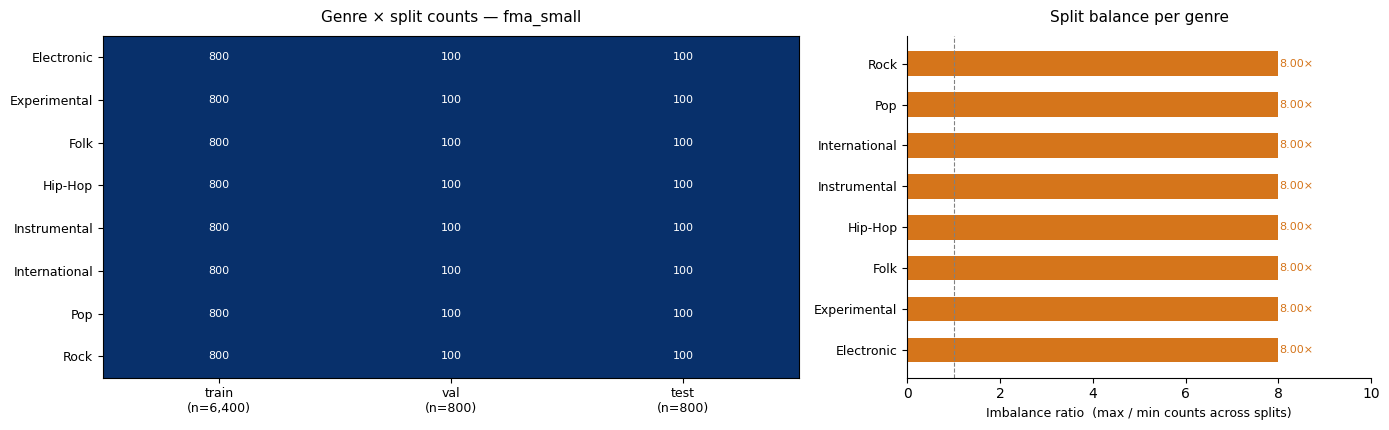

Most imbalanced genre across splits : Electronic  (ratio = 8.00×)
→ Significant imbalance detected — consider class-weighted loss or reporting Macro-F1 as the primary metric.

⏱  Genre distribution plot : 0.61s


In [35]:

_t0 = _time_module.perf_counter()

# ── Genre distribution: heatmap + imbalance ratio ─────────────────────────────
#
# Three-identical-bars is uninformative when splits are balanced (fma_small) and
# hard to compare when they are not (fma_medium).  This layout replaces it with:
#
#   Left  — annotated heatmap (genre × split, counts as colour + text).
#            Instantly shows whether any genre/split cell is sparse or missing.
#
#   Right — imbalance ratio per genre: max_count / min_count across the three
#           splits.  Ratio = 1.0 means perfectly balanced; higher values flag
#           genres that are over-represented in one split relative to another.
#           Sorted descending so the most imbalanced genres appear at the top.

split_names = ["train", "val", "test"]
dfs         = [train_df, val_df, test_df]
labels      = [f"{name}\n(n={len(df):,})" for name, df in zip(split_names, dfs)]

# Build (n_genres × 3) count matrix
genres_sorted = sorted(all_genres)
counts_matrix = np.array(
    [[df["genre_top"].value_counts().get(g, 0) for df in dfs] for g in genres_sorted],
    dtype=float,
)

# Normalise each split column to [0, 1] for colouring (so fma_small doesn't
# wash out to a flat colour when all values are equal)
col_max = counts_matrix.max(axis=0, keepdims=True)
col_max[col_max == 0] = 1
normed  = counts_matrix / col_max

# Imbalance ratio per genre
row_max  = counts_matrix.max(axis=1)
row_min  = counts_matrix.min(axis=1)
row_min[row_min == 0] = 1   # avoid division by zero for absent genres
imbalance = row_max / row_min
order_idx = np.argsort(imbalance)[::-1]   # most imbalanced first

fig, (ax_heat, ax_imb) = plt.subplots(
    1, 2,
    figsize=(14, max(4, len(genres_sorted) * 0.55)),
    gridspec_kw={"width_ratios": [3, 2]},
)

# ── Left: heatmap ─────────────────────────────────────────────────────────────
im = ax_heat.imshow(normed, aspect="auto", cmap="Blues", vmin=0, vmax=1)
ax_heat.set_xticks(range(3))
ax_heat.set_xticklabels(labels, fontsize=9)
ax_heat.set_yticks(range(len(genres_sorted)))
ax_heat.set_yticklabels(genres_sorted, fontsize=9)
ax_heat.set_title(f"Genre × split counts — fma_{SUBSET}", fontsize=11, pad=10)
for i, genre in enumerate(genres_sorted):
    for j in range(3):
        cnt = int(counts_matrix[i, j])
        text_col = "white" if normed[i, j] > 0.55 else "black"
        ax_heat.text(j, i, f"{cnt:,}", ha="center", va="center",
                     fontsize=8, color=text_col)

# ── Right: imbalance ratio ─────────────────────────────────────────────────────
y_pos = np.arange(len(genres_sorted))
ratios_sorted   = imbalance[order_idx]
genres_reordered = [genres_sorted[k] for k in order_idx]

bar_colors = ["#d5751b" if r > 1.5 else "#208dc4" for r in ratios_sorted]
ax_imb.barh(y_pos, ratios_sorted, color=bar_colors, height=0.6, edgecolor="none")
ax_imb.axvline(1.0, color="grey", linewidth=0.8, linestyle="--")
ax_imb.set_yticks(y_pos)
ax_imb.set_yticklabels(genres_reordered, fontsize=9)
ax_imb.set_xlabel("Imbalance ratio  (max / min counts across splits)", fontsize=9)
ax_imb.set_title("Split balance per genre", fontsize=11, pad=10)
# Annotate each bar with its ratio value
for y, r in zip(y_pos, ratios_sorted):
    ax_imb.text(r + 0.02, y, f"{r:.2f}×", va="center", fontsize=8,
                color="#d5751b" if r > 1.5 else "#208dc4")
ax_imb.set_xlim(0, ratios_sorted.max() * 1.25)
for spine in ["top", "right"]:
    ax_imb.spines[spine].set_visible(False)
ax_imb.invert_yaxis()

plt.tight_layout()
plt.show()

# ── Summary note ──────────────────────────────────────────────────────────────
worst_genre = genres_sorted[int(np.argmax(imbalance))]
worst_ratio = float(imbalance.max())
print(f"Most imbalanced genre across splits : {worst_genre}  "
      f"(ratio = {worst_ratio:.2f}×)")
if worst_ratio <= 1.05:
    print("→ All genres are near-perfectly balanced across splits.")
elif worst_ratio <= 2.0:
    print("→ Minor imbalance; using class-weighted loss is optional.")
else:
    print("→ Significant imbalance detected — consider class-weighted loss or "
          "reporting Macro-F1 as the primary metric.")

_section_times["3b. Genre plot"] = _time_module.perf_counter() - _t0
print(f"\n⏱  Genre distribution plot : {_section_times['3b. Genre plot']:.2f}s")



## 4. MFCC Feature Extraction

Each 30-second clip is loaded at `sr=22050 Hz`, and 13 MFCC coefficients are computed with
`n_fft=512`, `hop_length=256`, yielding a `(13, 2582)` spectrogram.
Shorter clips are zero-padded; longer ones are truncated.

Results are cached as `.npy` files so subsequent runs skip extraction entirely.

### The `dequantization failed` warning

During extraction you may see messages like:

```
[src/libmpg123/layer3.c:INT123_do_layer3():1844] error: dequantization failed!
```

**What it means:** libmpg123 (the C MP3 decoder) found a frame whose Huffman-coded
packet is corrupt or malformed. It cannot reconstruct the PCM samples for that ~26 ms
window, so it **zeros those samples and continues**. The audio array returned by
`librosa.load` has the correct length and the MFCC matrix has the correct shape, but
values for the affected time windows are wrong (silence instead of real signal).

**Why it doesn't crash:** The error is non-fatal — libmpg123 recovers automatically.
No Python exception is raised, so `load_mfcc` returns a seemingly valid array.
This is why the warning is easy to overlook.

**Impact in FMA:** Roughly 1–5 % of FMA tracks have at least one corrupt frame.
Each corrupt track contributes subtly wrong features to its MFCC matrix.

**Control via `SKIP_DEGRADED` (config cell):**

| `SKIP_DEGRADED` | Behaviour |
|---|---|
| `False` (default) | Tracks with corrupt frames are **included**. Degraded count is printed separately. Use this for the faithful FMA baseline. |
| `True` | Tracks with corrupt frames are **excluded** (treated as unreadable). Use this for cleaner input in your own model variants. Requires clearing the cache (`CLEAR_CACHE = True`) to take effect. |

The warning is detected by temporarily redirecting OS file descriptor 2 to a pipe during
`librosa.load()`, then scanning the captured output for libmpg123 error strings — the only
reliable way to catch C-library stderr inside a Python process.


In [ ]:

import hashlib
import librosa
import os

# ── C-level stderr capture (catches libmpg123 dequantization warnings) ────────
#
# Problem:  libmpg123 (the C MP3 decoder used by librosa) writes error messages
# such as "[layer3.c:…] error: dequantization failed!" directly to OS file
# descriptor 2. This bypasses Python's sys.stderr object entirely, so
# contextlib.redirect_stderr() cannot catch it.
#
# Cause:    "Dequantization failed" means that one or more frames in the MP3
# bitstream have a corrupt Huffman-coded packet.  libmpg123 recovers by zeroing
# those frames (silence/near-silence for ~26 ms per bad frame) and continues
# decoding.  The returned numpy array has the correct shape, but values for the
# affected time windows are wrong.
#
# Fix:      Temporarily replace fd 2 with a pipe, call librosa.load(), read the
# pipe after the call completes, then restore the original fd.  This is
# Linux-only, but safe inside a Jupyter kernel because fd 2 is restored in the
# `finally` block even if an exception is raised.

def _load_audio_with_stderr_capture(filepath, sr, mono=True, duration=30.0):
    """Load audio via librosa while capturing C-level stderr (OS fd 2)."""
    import fcntl as _fcntl

    r_fd, w_fd = os.pipe()
    old_fd = os.dup(2)
    sys.stderr.flush()
    os.dup2(w_fd, 2)
    os.close(w_fd)
    try:
        y, sr_out = librosa.load(
            str(filepath), sr=sr, mono=mono, duration=duration
        )
    finally:
        os.dup2(old_fd, 2)
        os.close(old_fd)
        _fcntl.fcntl(r_fd, _fcntl.F_SETFL,
                     _fcntl.fcntl(r_fd, _fcntl.F_GETFL) | os.O_NONBLOCK)
        try:
            buf = os.read(r_fd, 131_072)
        except BlockingIOError:
            buf = b""
        os.close(r_fd)

    return y, sr_out, buf.decode("utf-8", errors="replace")


def load_mfcc(filepath: Path) -> "tuple[np.ndarray | None, bool]":
    """Load one MP3 and return ``(mfcc, is_clean)``."""
    try:
        y, _, c_log = _load_audio_with_stderr_capture(
            filepath, sr=SAMPLE_RATE, mono=True, duration=30.0
        )
        is_clean = ("dequantization failed" not in c_log
                    and "error:" not in c_log.lower())
    except Exception as exc:
        print(f"  [WARN] Failed to load {filepath}: {exc}", file=sys.stderr)
        return None, False

    try:
        mfcc = librosa.feature.mfcc(
            y=y, sr=SAMPLE_RATE, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH
        )
        if mfcc.shape[1] < N_FRAMES:
            mfcc = np.pad(mfcc, ((0, 0), (0, N_FRAMES - mfcc.shape[1])), mode="constant")
        else:
            mfcc = mfcc[:, :N_FRAMES]
        return mfcc.astype(np.float32), is_clean
    except Exception as exc:
        print(f"  [WARN] MFCC failed for {filepath}: {exc}", file=sys.stderr)
        return None, False


def resolve_sample_id(row: pd.Series, track_id: int) -> str:
    source = str(row.get("source") or "fma")
    sample_id = row.get("sample_id")
    sample_id = "" if sample_id is None else str(sample_id).strip()
    if not sample_id or sample_id.lower() == "nan":
        sample_id = f"{source}:{track_id}"
    return sample_id


def split_fingerprint(split_df: pd.DataFrame) -> str:
    hasher = hashlib.sha1()
    identities = []
    for track_id, row in split_df.iterrows():
        identities.append(resolve_sample_id(row, int(track_id)))
    for sample_id in sorted(identities):
        hasher.update(sample_id.encode("utf-8"))
        hasher.update(b"\n")
    return hasher.hexdigest()[:12]


def extract_split(
    split_df: pd.DataFrame,
    split_name: str,
    label_enc: LabelEncoder,
    cache_dir: Path,
    subset: str,
    skip_degraded: bool = False,
) -> tuple:
    """Return ``(X, y)`` for one split, using the ``.npy`` cache when available."""
    cache_dir.mkdir(parents=True, exist_ok=True)
    fingerprint = split_fingerprint(split_df)
    x_path = cache_dir / f"mfcc_{split_name}_{subset}_{fingerprint}.npy"
    y_path = cache_dir / f"mfcc_{split_name}_{subset}_{fingerprint}_labels.npy"

    if x_path.exists() and y_path.exists():
        print(f"  [{split_name}] Loading from cache …")
        X = np.load(x_path)
        y = np.load(y_path)
        print(f"    X={X.shape}, y={y.shape}")
        return X, y

    print(f"  [{split_name}] Extracting MFCCs for {len(split_df):,} tracks …")
    Xs, ys, skipped, degraded = [], [], 0, 0
    t0 = time.time()

    for i, (_, row) in enumerate(split_df.iterrows()):
        mfcc, is_clean = load_mfcc(Path(row["filepath"]))
        if mfcc is None:
            skipped += 1
            continue
        if not is_clean:
            degraded += 1
            if skip_degraded:
                skipped += 1
                continue
        Xs.append(mfcc)
        ys.append(row["genre_top"])
        if (i + 1) % 500 == 0:
            pct = (i + 1) / len(split_df) * 100
            print(f"    {i+1}/{len(split_df)} ({pct:.0f}%)  "
                  f"skipped={skipped}  degraded({'excl' if skip_degraded else 'kept'})={degraded}  "
                  f"— {time.time()-t0:.0f}s elapsed")

    X = np.stack(Xs).astype(np.float32)
    y = label_enc.transform(np.array(ys)).astype(np.int32)
    total_attempted = len(Xs) + skipped
    pct_deg = degraded / max(1, total_attempted) * 100
    print(f"    Done : X={X.shape}, y={y.shape}")
    print(f"    Skipped  (unreadable)                      : {skipped}")
    print(f"    Degraded (corrupt frames, {'excl' if skip_degraded else 'kept'})     : "
          f"{degraded}  ({pct_deg:.1f} %)")
    np.save(x_path, X)
    np.save(y_path, y)
    print(f"    Cached → {cache_dir}")
    return X, y


In [29]:

_t0 = _time_module.perf_counter()

# ── Optional: clear cached .npy files ────────────────────────────────────────
if CLEAR_CACHE and CACHE_DIR.exists():
    import shutil
    shutil.rmtree(CACHE_DIR)
    print("Cache cleared.")

# ── Extract (or load from cache) ──────────────────────────────────────────────
# SKIP_DEGRADED controls whether tracks with libmpg123 decode warnings are kept.
# This flag only takes effect during extraction; cached .npy files are loaded
# as-is. To apply a changed value to an existing cache, set CLEAR_CACHE = True.
print("Extracting MFCCs (or loading from cache) …\n")
X_train, y_train = extract_split(train_df, "training",   label_enc, CACHE_DIR, SUBSET, SKIP_DEGRADED)
X_val,   y_val   = extract_split(val_df,   "validation", label_enc, CACHE_DIR, SUBSET, SKIP_DEGRADED)
X_test,  y_test  = extract_split(test_df,  "test",       label_enc, CACHE_DIR, SUBSET, SKIP_DEGRADED)

_section_times["4. MFCC extraction"] = _time_module.perf_counter() - _t0
print(f"\n⏱  MFCC extraction : {_section_times['4. MFCC extraction']:.1f}s")


Extracting MFCCs (or loading from cache) …

  [training] Extracting MFCCs for 6,400 tracks …
    500/6400 (8%)  skipped=0  degraded(kept)=1  — 198s elapsed
    1000/6400 (16%)  skipped=0  degraded(kept)=3  — 419s elapsed
    1500/6400 (23%)  skipped=0  degraded(kept)=3  — 682s elapsed
    2000/6400 (31%)  skipped=0  degraded(kept)=5  — 931s elapsed
    2500/6400 (39%)  skipped=0  degraded(kept)=5  — 1257s elapsed
    3000/6400 (47%)  skipped=0  degraded(kept)=5  — 1642s elapsed


/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/.venv311/lib/python3.11/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/.venv311/lib/python3.11/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/.venv311/lib/python3.11/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


    3500/6400 (55%)  skipped=0  degraded(kept)=8  — 2004s elapsed


/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/.venv311/lib/python3.11/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
  [WARN] Failed to load /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/FMA/fma_small/099/099134.mp3: 
/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/.venv311/lib/python3.11/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
  [WARN] Failed to load /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/FMA/fma_small/108/108925.mp3: 


    4000/6400 (62%)  skipped=2  degraded(kept)=8  — 2318s elapsed
    4500/6400 (70%)  skipped=2  degraded(kept)=8  — 2530s elapsed
    5000/6400 (78%)  skipped=2  degraded(kept)=8  — 2711s elapsed
    5500/6400 (86%)  skipped=2  degraded(kept)=8  — 2912s elapsed


/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/.venv311/lib/python3.11/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
  [WARN] Failed to load /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/FMA/fma_small/133/133297.mp3: 


    6000/6400 (94%)  skipped=3  degraded(kept)=8  — 3104s elapsed
    Done : X=(6397, 13, 2582), y=(6397,)
    Skipped  (unreadable)                      : 3
    Degraded (corrupt frames, kept)     : 8  (0.1 %)
    Cached → /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/cache
  [validation] Extracting MFCCs for 800 tracks …
    500/800 (62%)  skipped=0  degraded(kept)=0  — 179s elapsed


KeyboardInterrupt: 

In [ ]:
_t0 = _time_module.perf_counter()

# ── Visualise one example MFCC from the training set ─────────────────────────
idx   = 0
genre = GENRE_CLASSES[y_train[idx]]

fig, ax = plt.subplots(figsize=(14, 3))
img = ax.imshow(X_train[idx], aspect="auto", origin="lower",
                extent=[0, N_FRAMES * HOP_LENGTH / SAMPLE_RATE, 0, N_MFCC],
                cmap="magma")
ax.set_title(f"Sample MFCC — genre: {genre}  (train[{idx}])")
ax.set_xlabel("Time (s)")
ax.set_ylabel("MFCC coefficient")
plt.colorbar(img, ax=ax, label="Coefficient value")
plt.tight_layout()
plt.show()

_section_times["4b. MFCC plot"] = _time_module.perf_counter() - _t0
print(f"⏱  MFCC sample plot : {_section_times['4b. MFCC plot']:.2f}s")

## 5. Preprocessing

1. **Add channel dimension** — Conv2D expects `(N, H, W, C)`, so reshape `(N, 13, 2582)` → `(N, 13, 2582, 1)`.
2. **Standardise** — compute per-MFCC-coefficient mean and std over the training set; apply to val and test.
   This prevents any information from val/test leaking into normalisation statistics.
3. **One-hot encode** labels for `categorical_crossentropy`.

In [ ]:
_t0 = _time_module.perf_counter()

# ── Add channel dimension  (N, 13, 2582) → (N, 13, 2582, 1) ─────────────────
X_train = X_train[..., np.newaxis]
X_val   = X_val[...,   np.newaxis]
X_test  = X_test[...,  np.newaxis]

# ── Standardise (fit on train only) ─────────────────────────────────────────
mu  = X_train.mean(axis=(0, 2, 3), keepdims=True)
std = X_train.std( axis=(0, 2, 3), keepdims=True) + 1e-8
X_train = (X_train - mu) / std
X_val   = (X_val   - mu) / std
X_test  = (X_test  - mu) / std

# ── One-hot encode labels ────────────────────────────────────────────────────
y_train_oh = tf.keras.utils.to_categorical(y_train, N_CLASSES)
y_val_oh   = tf.keras.utils.to_categorical(y_val,   N_CLASSES)

print(f"X_train : {X_train.shape}  dtype={X_train.dtype}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train_oh : {y_train_oh.shape}")
print(f"\nNormalisation — mean range : [{mu.min():.2f}, {mu.max():.2f}]")
print(f"             — std  range : [{std.min():.2f}, {std.max():.2f}]")

_section_times["5. Preprocessing"] = _time_module.perf_counter() - _t0
print(f"\n⏱  Preprocessing : {_section_times['5. Preprocessing']:.2f}s")

## 6. Build the CNN Model

Direct Keras translation of the original FMA architecture.
No batch normalisation, no dropout — kept faithful to the original paper.

In [ ]:
_t0 = _time_module.perf_counter()

def build_model(n_classes: int) -> keras.Model:
    """2D CNN on MFCC spectrograms — faithful to FMA baselines.ipynb §3.1.

    Conv2D(3,  (13,10), stride (1,4)) → (1,  644,  3)
    Conv2D(15, (1, 10), stride (1,4)) → (1,  159, 15)
    Conv2D(65, (1, 10), stride (1,4)) → (1,   38, 65)
    Flatten                           → (2470,)
    Dense(n_classes, softmax)
    """
    inputs = keras.Input(shape=(*MFCC_SHAPE, 1), name="mfcc")   # (13, 2582, 1)

    x = layers.Conv2D(3,  (13, 10), strides=(1, 4), padding="valid",
                      activation="relu", name="conv1")(inputs)
    x = layers.Conv2D(15, (1,  10), strides=(1, 4), padding="valid",
                      activation="relu", name="conv2")(x)
    x = layers.Conv2D(65, (1,  10), strides=(1, 4), padding="valid",
                      activation="relu", name="conv3")(x)
    x = layers.Flatten(name="flatten")(x)
    outputs = layers.Dense(n_classes, activation="softmax", name="fc_out")(x)

    return keras.Model(inputs, outputs, name="mfcc_2dcnn_baseline")


with tf.device(RUNTIME_DEVICE):
    model = build_model(N_CLASSES)

model.summary()

_section_times["6. Build model"] = _time_module.perf_counter() - _t0
print(f"\n⏱  Build model : {_section_times['6. Build model']:.2f}s")

## 7. Compile & Train

Optimizer, loss, and epoch count are identical to the original FMA baseline.
`shuffle=True` is set to randomise the order within each epoch.

In [ ]:
_t0 = _time_module.perf_counter()

with tf.device(RUNTIME_DEVICE):
    model.compile(
        optimizer=tf.keras.optimizers.SGD(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

print(f"Training on {RUNTIME_DEVICE}  |  epochs={EPOCHS}, batch_size={BATCH_SIZE}\n")

with tf.device(RUNTIME_DEVICE):
    history = model.fit(
        X_train, y_train_oh,
        validation_data=(X_val, y_val_oh),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=True,
    )

# ── Save model ────────────────────────────────────────────────────────────────
MODELS_DIR.mkdir(parents=True, exist_ok=True)
model_path = MODELS_DIR / "baseline_mfcc_cnn.keras"
model.save(str(model_path))
print(f"\nModel saved → {model_path}")

_section_times["7. Compile & train"] = _time_module.perf_counter() - _t0
print(f"\n⏱  Compile & train : {_section_times['7. Compile & train']:.1f}s  "
      f"({_section_times['7. Compile & train']/EPOCHS:.1f}s per epoch)")

## 8. Training History

Plot accuracy and loss curves over epochs for both train and validation sets.
A growing gap between the two curves signals overfitting.

In [ ]:
_t0 = _time_module.perf_counter()

hist = history.history
epochs_range = range(1, len(hist["accuracy"]) + 1)

fig, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize=(13, 4))

# Accuracy
ax_acc.plot(epochs_range, hist["accuracy"],     label="Train",      linewidth=2)
ax_acc.plot(epochs_range, hist["val_accuracy"], label="Validation", linewidth=2, linestyle="--")
ax_acc.set_title("Accuracy")
ax_acc.set_xlabel("Epoch")
ax_acc.set_ylabel("Accuracy")
ax_acc.legend()
ax_acc.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
for spine in ["top", "right"]:
    ax_acc.spines[spine].set_visible(False)

# Loss
ax_loss.plot(epochs_range, hist["loss"],     label="Train",      linewidth=2)
ax_loss.plot(epochs_range, hist["val_loss"], label="Validation", linewidth=2, linestyle="--")
ax_loss.set_title("Loss")
ax_loss.set_xlabel("Epoch")
ax_loss.set_ylabel("Categorical cross-entropy")
ax_loss.legend()
ax_loss.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
for spine in ["top", "right"]:
    ax_loss.spines[spine].set_visible(False)

fig.suptitle("Training history — MFCC 2D CNN baseline", fontsize=13)
plt.tight_layout()
plt.show()

final_train_acc = hist["accuracy"][-1]
final_val_acc   = hist["val_accuracy"][-1]
print(f"Final train accuracy : {final_train_acc:.4f}  ({final_train_acc:.2%})")
print(f"Final val   accuracy : {final_val_acc:.4f}  ({final_val_acc:.2%})")

_section_times["8. Training history plot"] = _time_module.perf_counter() - _t0
print(f"\n⏱  Training history plot : {_section_times['8. Training history plot']:.2f}s")

## 9. Evaluate the Model

Report accuracy, Macro-F1, and per-genre F1 on all three splits.
Results are also saved to `MelCNN-MGR/results/baseline_mfcc_cnn_results.txt`.

In [ ]:
_t0 = _time_module.perf_counter()

def evaluate_split(model, X, y_true_int, genre_classes, split_label: str) -> str:
    """Print and return a formatted accuracy + Macro-F1 + per-genre report."""
    y_pred = np.argmax(model.predict(X, batch_size=64, verbose=0), axis=1)
    acc      = accuracy_score(y_true_int, y_pred)
    macro_f1 = f1_score(y_true_int, y_pred, average="macro", zero_division=0)
    report   = classification_report(y_true_int, y_pred,
                                     target_names=genre_classes, zero_division=0)
    block = (
        f"\n{'='*60}\n {split_label}\n{'='*60}\n"
        f"  Accuracy : {acc:.4f}  ({acc:.2%})\n"
        f"  Macro-F1 : {macro_f1:.4f}\n\n"
        f"Per-genre classification report:\n{report}"
    )
    print(block)
    return block


results_lines: list[str] = [
    "FMA Baseline Reproducer — MFCC → 2D CNN\n",
    f"Epochs={EPOCHS}, batch_size={BATCH_SIZE}\n",
    f"Training samples  : {len(X_train)}\n"
    f"Validation samples: {len(X_val)}\n"
    f"Test samples      : {len(X_test)}\n",
]

with tf.device(RUNTIME_DEVICE):
    results_lines.append(evaluate_split(model, X_train, y_train, GENRE_CLASSES, "TRAIN SET"))
    results_lines.append(evaluate_split(model, X_val,   y_val,   GENRE_CLASSES, "VALIDATION SET"))
    results_lines.append(evaluate_split(model, X_test,  y_test,  GENRE_CLASSES, "TEST SET"))

# Save results to file
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
result_path = RESULTS_DIR / "baseline_mfcc_cnn_results.txt"
result_path.write_text("\n".join(results_lines), encoding="utf-8")
print(f"\nResults saved → {result_path}")

_section_times["9. Evaluation"] = _time_module.perf_counter() - _t0
print(f"\n⏱  Evaluation : {_section_times['9. Evaluation']:.1f}s")

In [ ]:
_t0 = _time_module.perf_counter()

# ── Confusion matrix (test set) ───────────────────────────────────────────────
y_pred_test = np.argmax(model.predict(X_test, batch_size=64, verbose=0), axis=1)
cm = confusion_matrix(y_test, y_pred_test)

fig, ax = plt.subplots(figsize=(13, 11))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=GENRE_CLASSES)
disp.plot(ax=ax, xticks_rotation=45, colorbar=True, cmap="Blues", values_format="d")
ax.set_title("Confusion matrix — test set", fontsize=13, pad=14)
plt.tight_layout()
plt.show()

_section_times["9b. Confusion matrix"] = _time_module.perf_counter() - _t0
print(f"⏱  Confusion matrix : {_section_times['9b. Confusion matrix']:.2f}s")

## 10. Predict on a New Audio Sample

Set `INFER_PATH` to any MP3 file to predict its genre with the trained model.
By default this cell re-uses a random sample from the test set so it runs without
additional files.

In [ ]:
_t0 = _time_module.perf_counter()

# ── Set to an MP3 path to run on a real file, or leave None to use a test sample ──
INFER_PATH = None   # e.g. Path("/path/to/my_track.mp3")

if INFER_PATH is None:
    # Fall back to a random test-set track
    rng_idx    = np.random.randint(len(test_df))
    INFER_PATH = Path(test_df.iloc[rng_idx]["filepath"])
    true_genre = test_df.iloc[rng_idx]["genre_top"]
    print(f"Using test sample: {INFER_PATH.name}  (true genre: {true_genre})")
else:
    true_genre = "?"

# Extract MFCC
mfcc = load_mfcc(Path(INFER_PATH))
if mfcc is None:
    print("Could not load audio file.")
else:
    # Normalise using training statistics, add batch + channel dims
    x_infer = ((mfcc[np.newaxis, ..., np.newaxis] - mu) / std).astype(np.float32)

    probs      = model.predict(x_infer, verbose=0)[0]
    pred_idx   = int(np.argmax(probs))
    pred_genre = GENRE_CLASSES[pred_idx]
    confidence = float(probs[pred_idx])

    print(f"\nPredicted genre : {pred_genre}  (confidence: {confidence:.2%})")
    print(f"True genre      : {true_genre}")

    # Bar chart of class probabilities
    fig, ax = plt.subplots(figsize=(10, 3))
    colors = ["steelblue" if g != pred_genre else "tomato" for g in GENRE_CLASSES]
    ax.barh(GENRE_CLASSES, probs, color=colors)
    ax.set_xlabel("Probability")
    ax.set_title(f"Genre probabilities — {INFER_PATH.name}")
    ax.axvline(1 / N_CLASSES, color="grey", linestyle="--", linewidth=0.8,
               label=f"Chance ({1/N_CLASSES:.2%})")
    ax.legend(fontsize=9)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    plt.tight_layout()
    plt.show()

_section_times["10. Inference"] = _time_module.perf_counter() - _t0
print(f"\n⏱  Inference : {_section_times['10. Inference']:.2f}s")

---

## Runtime Summary

In [ ]:
_total = _time_module.perf_counter() - _T0

SEP = "=" * 52
print(SEP)
print("  Runtime summary")
print(SEP)
for section, elapsed in _section_times.items():
    bar_len  = max(1, int(elapsed / _total * 30))
    bar      = "█" * bar_len
    pct      = elapsed / _total * 100
    mins, secs = divmod(elapsed, 60)
    time_str = f"{int(mins)}m {secs:04.1f}s" if mins else f"{elapsed:6.1f}s"
    print(f"  {section:<28}  {time_str:>9}  {pct:5.1f}%  {bar}")

print(SEP)
mins_total, secs_total = divmod(_total, 60)
total_str = f"{int(mins_total)}m {secs_total:04.1f}s" if mins_total else f"{_total:.1f}s"
print(f"  {'TOTAL':<28}  {total_str:>9}")
print(SEP)